# Exploratory Data Analysis (EDA)

### Import Libraries

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

### Load Dataset

In [10]:
loan_df = pd.read_csv("../dataset/loan_approval_dataset.csv")

# Clean column names
loan_df.columns = loan_df.columns.str.strip()

### Set Plot Style

In [3]:
plt.style.use("ggplot")
plt.rcParams["figure.figsize"] = (8, 5)

### Target Variable Distribution

In [11]:
loan_df["loan_status"].value_counts()

loan_status
 Approved    2656
 Rejected    1613
Name: count, dtype: int64

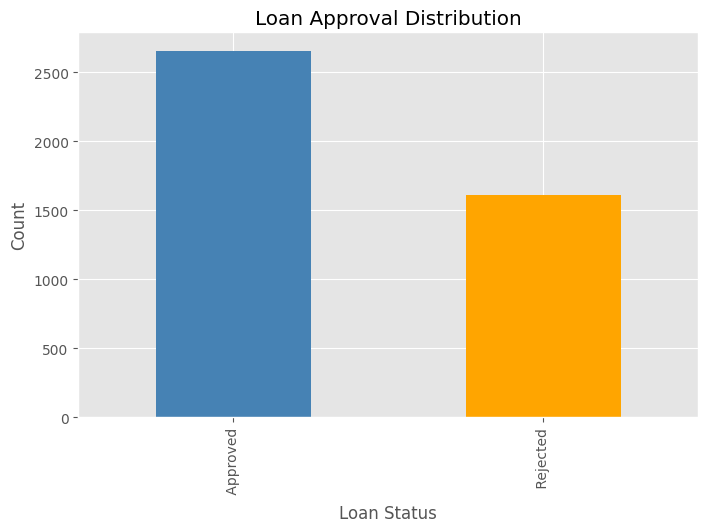

In [12]:
loan_df['loan_status'].value_counts().plot(
    kind='bar',
    color=['steelblue', 'orange']
)

plt.title("Loan Approval Distribution")
plt.xlabel("Loan Status")
plt.ylabel("Count")

plt.show()

### Percentage Distribution

In [13]:
loan_df['loan_status'].value_counts(normalize=True) * 100

loan_status
 Approved    62.215976
 Rejected    37.784024
Name: proportion, dtype: float64

### Check Categorical Features

In [16]:
loan_df['education'].value_counts()

education
 Graduate        2144
 Not Graduate    2125
Name: count, dtype: int64

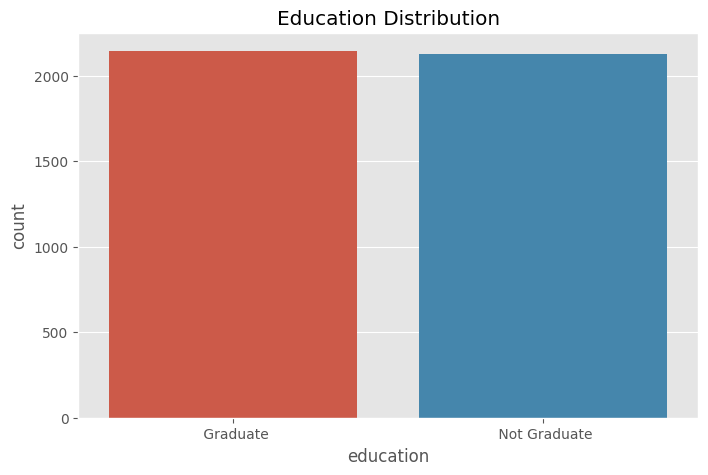

In [18]:
plt.Figure(figsize=(6, 4))

sns.countplot(
    data=loan_df,
    x='education',
)

plt.title("Education Distribution")

plt.show()

In [20]:
loan_df['self_employed'].value_counts()

self_employed
 Yes    2150
 No     2119
Name: count, dtype: int64

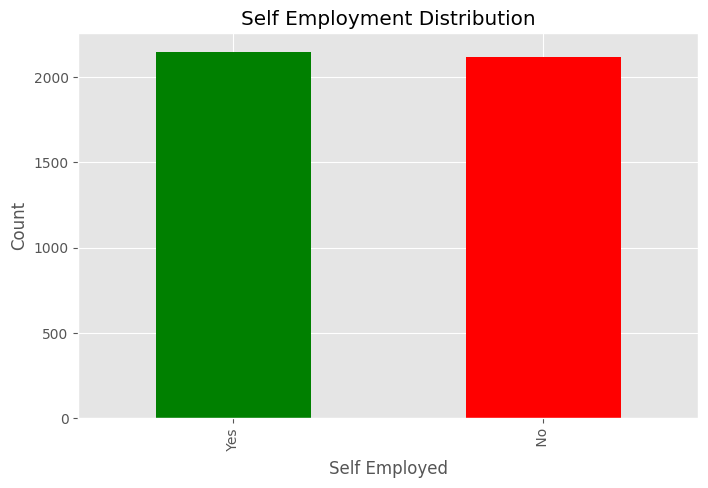

In [21]:
loan_df["self_employed"].value_counts().plot(
    kind="bar",
    color=["green", "red"]
)

plt.title("Self Employment Distribution")
plt.xlabel("Self Employed")
plt.ylabel("Count")
plt.show()

### Education vs Loan Status

In [22]:
pd.crosstab(
    loan_df["education"],
    loan_df["loan_status"]
)

loan_status,Approved,Rejected
education,,
Graduate,1339,805
Not Graduate,1317,808


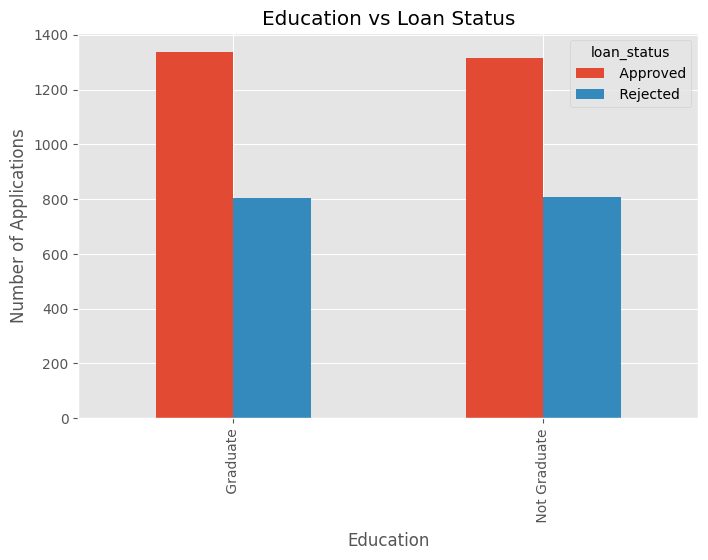

In [23]:
pd.crosstab(
    loan_df["education"],
    loan_df["loan_status"]
).plot(
    kind="bar",
    figsize=(8, 5)
)

plt.title("Education vs Loan Status")
plt.xlabel("Education")
plt.ylabel("Number of Applications")

plt.show()

### Self Employed vs Loan Status

In [24]:
pd.crosstab(
    loan_df["self_employed"],
    loan_df["loan_status"]
)

loan_status,Approved,Rejected
self_employed,,
No,1318,801
Yes,1338,812


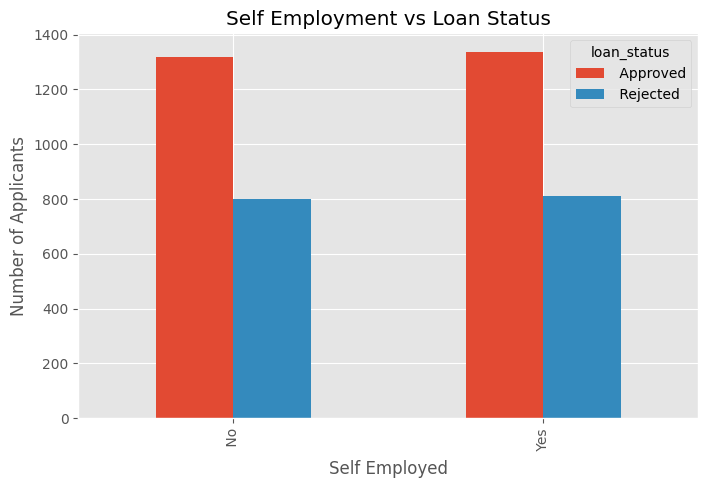

In [25]:
pd.crosstab(
    loan_df["self_employed"],
    loan_df["loan_status"]
).plot(
    kind="bar",
    figsize=(8, 5)
)

plt.title("Self Employment vs Loan Status")
plt.xlabel("Self Employed")
plt.ylabel("Number of Applicants")

plt.show()

### CIBIL Score Distribution

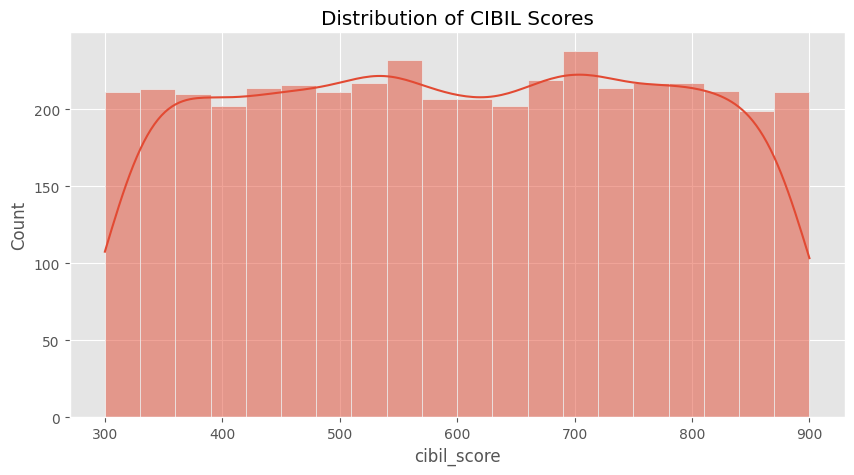

In [26]:
plt.figure(figsize=(10, 5))

sns.histplot(
    loan_df["cibil_score"],
    bins=20,
    kde=True
)

plt.title("Distribution of CIBIL Scores")

plt.show()

### Income Distribution

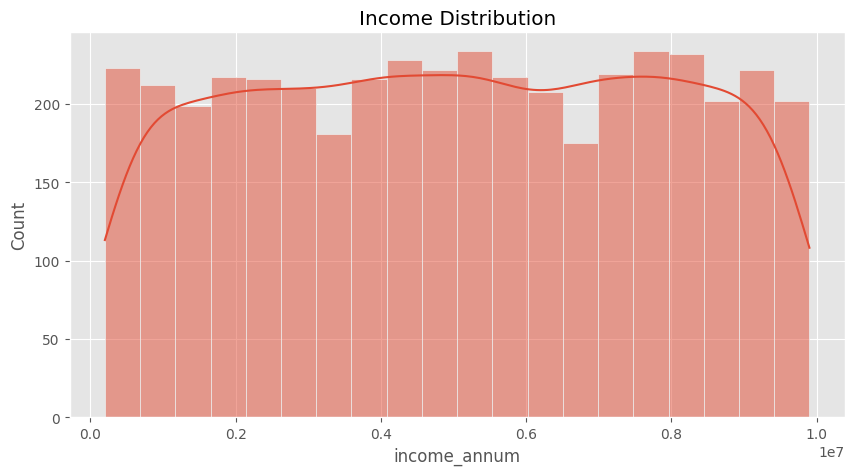

In [27]:
plt.figure(figsize=(10, 5))

sns.histplot(
    loan_df["income_annum"],
    bins=20,
    kde=True
)

plt.title("Income Distribution")

plt.show()

### Convert Categorical Columns to Numbers

In [28]:
corr_df = loan_df.copy()

In [29]:
corr_df["education"] = corr_df["education"].map({
    "Graduate": 1,
    "Not Graduate": 0
})

corr_df["self_employed"] = corr_df["self_employed"].map({
    "Yes": 1,
    "No": 0
})

corr_df["loan_status"] = corr_df["loan_status"].map({
    "Approved": 1,
    "Rejected": 0
})

### Calculate Correlation

In [30]:
corr_df.corr()

,loan_id,no_of_dependents,education,self_employed,income_annum,loan_amount,loan_term,cibil_score,residential_assets_value,commercial_assets_value,luxury_assets_value,bank_asset_value,loan_status
loan_id,1.000000,0.005326,NaN,NaN,0.012592,0.008170,0.009809,0.016323,0.020936,0.018595,-0.000862,0.010765,NaN
no_of_dependents,0.005326,1.000000,NaN,NaN,0.007266,-0.003366,-0.020111,-0.009998,0.007376,-0.001531,0.002817,0.011163,NaN
education,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
self_employed,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
income_annum,0.012592,0.007266,NaN,NaN,1.000000,0.927470,0.011488,-0.023034,0.636841,0.640328,0.929145,0.851093,NaN
loan_amount,0.008170,-0.003366,NaN,NaN,0.927470,1.000000,0.008437,-0.017035,0.594596,0.603188,0.860914,0.788122,NaN
loan_term,0.009809,-0.020111,NaN,NaN,0.011488,0.008437,1.000000,0.007810,0.008016,-0.005478,0.012490,0.017177,NaN
cibil_score,0.016323,-0.009998,NaN,NaN,-0.023034,-0.017035,0.007810,1.000000,-0.019947,-0.003769,-0.028618,-0.015478,NaN
residential_assets_value,0.020936,0.007376,NaN,NaN,0.636841,0.594596,0.008016,-0.019947,1.000000,0.414786,0.590932,0.527418,NaN
commercial_assets_value,0.018595,-0.001531,NaN,NaN,0.640328,0.603188,-0.005478,-0.003769,0.414786,1.000000,0.591128,0.548576,NaN


### Visualize with a Heatmap

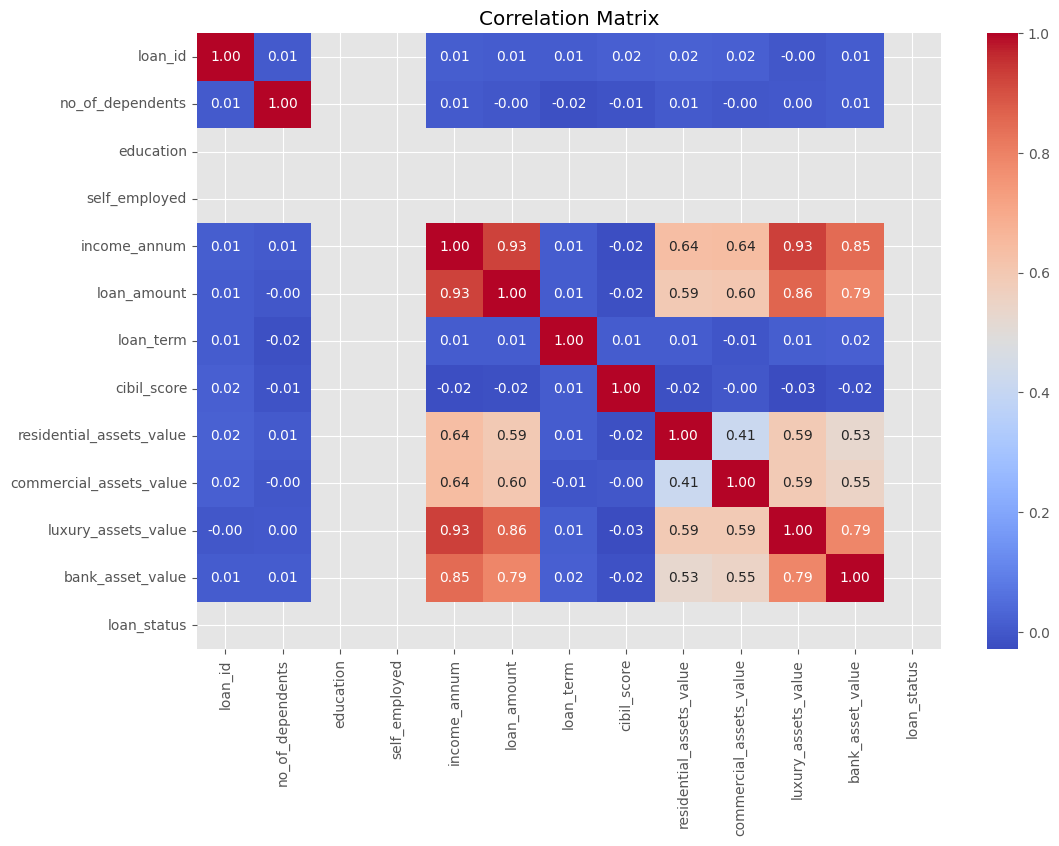

In [31]:
plt.figure(figsize=(12, 8))

sns.heatmap(
    corr_df.corr(),
    annot=True,
    cmap="coolwarm",
    fmt=".2f"
)

plt.title("Correlation Matrix")

plt.show()